In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [42]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
train_dataset = pd.read_csv(
    "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/train_dataset_v5_lane_vehicle.csv"
)

test_dataset = pd.read_csv(
    "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/test_dataset_v5_lane_vehicle.csv"
)

print(train_dataset.shape)
print(test_dataset.shape)

(242965, 174)
(66060, 174)


In [44]:
behavior_map = {
    "NORMAL1": "NORMAL",
    "NORMAL2": "NORMAL"
}

train_dataset["behavior"] = train_dataset["behavior"].replace(behavior_map)
test_dataset["behavior"] = test_dataset["behavior"].replace(behavior_map)

In [45]:
ttc_columns = [
    "ttc_mean",
    "ttc_std",
    "ttc_variance",
    "ttc_min",
    "ttc_max",
    "ttc_median",
    "ttc_rms",
    "ttc_skewness",
    "ttc_kurtosis",
    "ttc_q25",
    "ttc_q75",
    "ttc_iqr"
]

for col in ttc_columns:

    if col in train_dataset.columns:

        if any(x in col for x in [
            "std",
            "variance",
            "iqr",
            "skewness",
            "kurtosis"
        ]):

            train_dataset[col] = train_dataset[col].fillna(0)
            test_dataset[col] = test_dataset[col].fillna(0)

        else:

            train_dataset[col] = train_dataset[col].fillna(100)
            test_dataset[col] = test_dataset[col].fillna(100)

train_dataset = train_dataset.fillna(0)
test_dataset = test_dataset.fillna(0)

print(train_dataset.isnull().sum().sum())
print(test_dataset.isnull().sum().sum())

0
0


In [46]:
target_column = "behavior"

feature_columns = [

    col

    for col in train_dataset.columns

    if col not in [

        "behavior",
        "driver",
        "trip",
        "road_type"

    ]

]

X_train = train_dataset[feature_columns]

X_test = test_dataset[feature_columns]

y_train = train_dataset[target_column]

y_test = test_dataset[target_column]

print(X_train.shape)
print(X_test.shape)

(242965, 170)
(66060, 170)


In [47]:
train_dataset["behavior"] = (
    train_dataset["behavior"]
    .replace({
        "NORMAL1": "NORMAL",
        "NORMAL2": "NORMAL"
    })
)

test_dataset["behavior"] = (
    test_dataset["behavior"]
    .replace({
        "NORMAL1": "NORMAL",
        "NORMAL2": "NORMAL"
    })
)

In [48]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print(label_encoder.classes_)

['AGGRESSIVE' 'DROWSY' 'NORMAL']


In [49]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Model trained successfully!")

Model trained successfully!


In [50]:
rf_pred = rf_model.predict(X_test)

rf_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [51]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(f"Random Forest Accuracy : {rf_accuracy:.4f}")

Random Forest Accuracy : 0.6302


In [52]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

  AGGRESSIVE       0.85      0.75      0.80     15257
      DROWSY       0.81      0.53      0.65     36143
      NORMAL       0.38      0.74      0.50     14660

    accuracy                           0.63     66060
   macro avg       0.68      0.68      0.65     66060
weighted avg       0.72      0.63      0.65     66060



In [53]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(30)

,Feature,Importance
138,relative_speed_rms,0.036088
28,speed_max,0.033134
34,speed_q75,0.025328
94,lane_offset_q75,0.023901
29,speed_median,0.023370
33,speed_q25,0.022752
88,lane_offset_max,0.021494
24,speed_mean,0.021442
30,speed_rms,0.020563
27,speed_min,0.017909


In [54]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

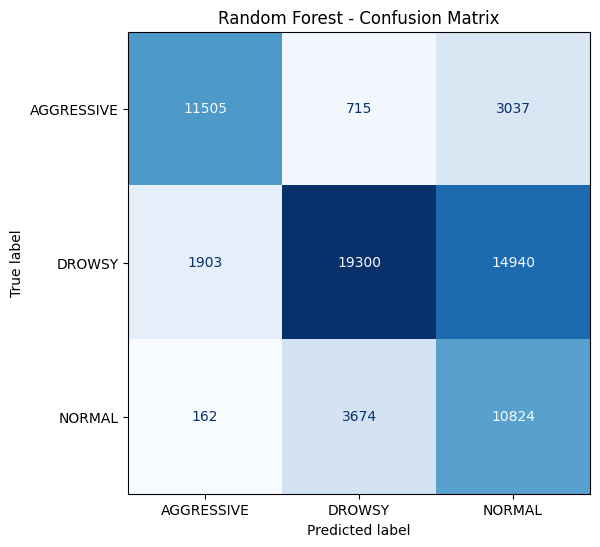

In [55]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Random Forest - Confusion Matrix")

plt.show()

In [56]:
print(cm)

[[11505   715  3037]
 [ 1903 19300 14940]
 [  162  3674 10824]]
